# 05 - Agreement Analysis

This notebook brings together the outputs of the three anomaly detectors built in notebooks 02 to 04 and checks how much they actually agree with each other across the S&P 500, 2015 to 2025.

Three things are measured:
- Formal agreement metrics (Cohen's kappa, Jaccard) for each pair of detectors, so agreement is measured directly rather than eyeballed from charts.
- A full partition of every flagged stock-day into one of seven buckets: all three detectors agree, one of the three pairs agrees, or only a single detector flagged it. These sets are the raw material for the event study in notebook 06.
- Whether the three detectors are actually measuring different things, or whether two of them are effectively redundant.

**Outputs**
- `data/agreement_verdicts.parquet`, the boolean flag matrix (`stat`, `iso`, `lstm`) for every stock-day scored by all three detectors
- `data/agreement_partition.csv`, the count of stock-days in each of the seven agreement buckets
- `results/three_way_venn.png`, a Venn diagram of the three detectors' flagged days

## 1. Loading and Aligning Detector Outputs

Load all three detector outputs and align them on the stock-days scored by all three. The LSTM uses a 30-day rolling window, so the first 30 trading days of each stock have no LSTM verdict; those rows are dropped so the comparison is on equal footing across all three detectors.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data")

d1 = pd.read_parquet(DATA_DIR / "detector1_statistical.parquet")
d2 = pd.read_parquet(DATA_DIR / "detector2_isolation_forest.parquet")
d3 = pd.read_parquet(DATA_DIR / "detector3_lstm.parquet")

# align all three on the stock-days ALL of them scored
verdicts = pd.DataFrame({
    "stat": d1["stat_anomaly"],
    "iso":  d2["iso_anomaly"],
    "lstm": d3["lstm_anomaly"],
}).dropna() # dropna: LSTM's 30-day rolling window means each stock's first 30 days have no LSTM verdict


print("Aligned stock-days scored by all three detectors:", verdicts.shape)
verdicts = verdicts.astype(bool)
print(verdicts.sum())

Aligned stock-days scored by all three detectors: (1169720, 3)
stat    8198
iso     8253
lstm    8189
dtype: int64


## 2. Three-Way Partition

With three detectors, every flagged stock-day falls into exactly one of seven buckets: all three agree, one of the three pairs agrees, or only one detector flagged it alone.

In [3]:
s, i, l = verdicts["stat"], verdicts["iso"], verdicts["lstm"]

partition = {
    "all_three":  ( s &  i &  l).sum(),
    "stat_iso":   ( s &  i & ~l).sum(),
    "stat_lstm":  ( s & ~i &  l).sum(),
    "iso_lstm":   (~s &  i &  l).sum(),
    "stat_only":  ( s & ~i & ~l).sum(),
    "iso_only":   (~s &  i & ~l).sum(),
    "lstm_only":  (~s & ~i &  l).sum(),
}

for k, v in partition.items():
    print(f"{k:12s}: {v:6d}")

total_flagged = (s | i | l).sum()
print(f"\nTotal unique stock-days flagged by at least one: {total_flagged}")
print(f"All-three agreement: {100*partition['all_three']/total_flagged:.1f}% of flagged days")

all_three   :     13
stat_iso    :   1125
stat_lstm   :     70
iso_lstm    :     29
stat_only   :   6990
iso_only    :   7086
lstm_only   :   8077

Total unique stock-days flagged by at least one: 23390
All-three agreement: 0.1% of flagged days


## 3. Formal Agreement Metrics: Cohen's κ and Jaccard

Cohen's kappa measures agreement beyond what would be expected by chance, and the Jaccard index measures the overlap between two flagged sets relative to their union. Both are computed for each pair of detectors.

In [4]:
from sklearn.metrics import cohen_kappa_score

pairs = [("stat", "iso"), ("stat", "lstm"), ("iso", "lstm")]
print("Pairwise agreement metrics:\n")
for a, b in pairs:
    kappa = cohen_kappa_score(verdicts[a], verdicts[b])
    both = (verdicts[a] & verdicts[b]).sum()
    either = (verdicts[a] | verdicts[b]).sum()
    jaccard = both / either
    print(f"{a:5s} vs {b:5s}:  Cohen's κ = {kappa:.3f}   Jaccard = {jaccard:.3f}")

Pairwise agreement metrics:

stat  vs iso  :  Cohen's κ = 0.132   Jaccard = 0.074
stat  vs lstm :  Cohen's κ = 0.003   Jaccard = 0.005
iso   vs lstm :  Cohen's κ = -0.002   Jaccard = 0.003


## 4. Saving Agreement Outputs

Persist the verdict matrix and partition counts, which the event study in notebook 06 uses to define its comparison groups.

In [5]:
# save the partition counts and the full verdict matrix for the event study
verdicts.to_parquet(DATA_DIR / "agreement_verdicts.parquet")

partition_df = pd.DataFrame(list(partition.items()), columns=["set", "count"])
partition_df.to_csv(DATA_DIR / "agreement_partition.csv", index=False)
print("Saved verdicts and partition.")

Saved verdicts and partition.


## 5. Visualizing Detector Agreement

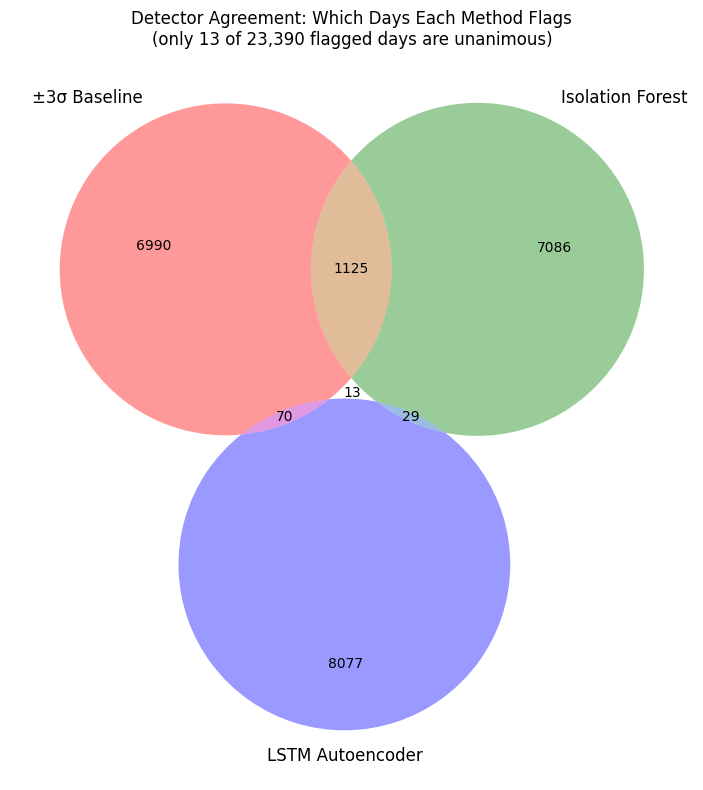

In [6]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# venn3 wants subsets in this order:
# (stat_only, iso_only, stat∩iso_only, lstm_only, stat∩lstm_only, iso∩lstm_only, all_three)
subsets = (
    partition["stat_only"],   # stat only
    partition["iso_only"],    # iso only
    partition["stat_iso"],    # stat ∩ iso (not lstm)
    partition["lstm_only"],   # lstm only
    partition["stat_lstm"],   # stat ∩ lstm (not iso)
    partition["iso_lstm"],    # iso ∩ lstm (not stat)
    partition["all_three"],   # all three
)

fig, ax = plt.subplots(figsize=(9, 8))
v = venn3(
    subsets=subsets,
    set_labels=("±3σ Baseline", "Isolation Forest", "LSTM Autoencoder"),
    ax=ax,
)
ax.set_title("Detector Agreement: Which Days Each Method Flags\n(only 13 of 23,390 flagged days are unanimous)")
plt.tight_layout()
plt.show()
fig.savefig("../results/three_way_venn.png", dpi=150, bbox_inches="tight")

### Three-Way Agreement: The Detectors Barely Overlap

This Venn diagram shows which stock-days each detector flagged. Each circle is one detector, and overlaps are days flagged by more than one.

The striking feature is how little the circles overlap. Each detector has a large private region, roughly 7,000 to 8,000 days it flags that neither other method catches. The shared regions are tiny by comparison: the baseline and Isolation Forest share 1,125 days, but the LSTM barely overlaps either one (70 and 29 days), and all three agree on just 13 days out of 23,390 flagged, which is 0.1%.

The three methods are effectively orthogonal, each identifying a distinct population of anomalous days. This matches the agreement statistics above, where Cohen's kappa ranges from -0.002 to 0.132, all near or below what chance agreement would produce. Rather than three versions of the same detector, this looks like three genuinely different lenses on what counts as anomalous: return surprise for the ±3σ baseline, rarity of feature-state for the Isolation Forest, and temporal pattern-break for the LSTM. This large disagreement is exactly what makes the next step worth doing: testing whether these disagreements predict future returns.